In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression ,LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,Normalizer,MinMaxScaler
from sklearn.metrics import confusion_matrix

In [13]:
df =pd.read_csv("social.csv")
x=df.iloc[:,2:4]
y=df.iloc[:,4]

In [14]:
print(df)

      User ID  Gender  Age  EstimatedSalary  Purchased
0    15624510    Male   19            19000          0
1    15810944    Male   35            20000          0
2    15668575  Female   26            43000          0
3    15603246  Female   27            57000          0
4    15804002    Male   19            76000          0
..        ...     ...  ...              ...        ...
395  15691863  Female   46            41000          1
396  15706071    Male   51            23000          1
397  15654296  Female   50            20000          1
398  15755018    Male   36            33000          0
399  15594041  Female   49            36000          1

[400 rows x 5 columns]


In [15]:
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.25)

In [6]:
print(x_train)
# print(x_test)
print(y_train)

     Age  EstimatedSalary
239   53           143000
86    24            55000
317   35            55000
71    24            27000
390   48            33000
..   ...              ...
91    30           116000
120   36            75000
384   57            33000
131   33            31000
154   40            47000

[300 rows x 2 columns]
239    1
86     0
317    0
71     0
390    1
      ..
91     0
120    0
384    1
131    0
154    0
Name: Purchased, Length: 300, dtype: int64


In [16]:
x_sca=StandardScaler()
x_train=x_sca.fit_transform(x_train)
x_test=x_sca.transform(x_test)


In [17]:
clf=LogisticRegression(random_state=0)
clf.fit(x_train,y_train)

LogisticRegression(random_state=0)

In [18]:
y_pread=clf.predict(x_test)
print(y_pread)
# y_pread2=clf.predict(x_train)
# print(y_pread2)

[0 0 0 1 0 1 0 1 0 0 1 0 0 0 1 0 0 1 1 1 1 0 0 0 0 1 0 0 1 1 0 1 0 0 0 1 0
 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1]


In [19]:
cm=confusion_matrix(y_test,y_pread)
cm

array([[56,  2],
       [14, 28]], dtype=int64)

In [36]:
# import matplotlib.pyplot as plt
# from matplotlib.colors import ListedColormap
# x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.25)
# x_set, y_set = x_train, y_train

# # generates every pixel in the table. meshgrid creates one entry point x1 to x2
# x1, x2 = np.meshgrid(
#     np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01),
#     np.arange(start=x_set[:, 1].min() - 1, stop=x_set[:, 1].max() + 1, step=0.01)
# )

# # classifies every pixel as 0 or 1
# plt.contourf(x1, x2, clf.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
#              alpha=0.75, cmap=ListedColormap(("red", "green")))

# for i, j in enumerate(np.unique(y_set)):
#     plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
#                 c=ListedColormap(("red", "green"))(i), label=j, edgecolor="black")

# plt.xlim(x1.min(), x1.max())
# plt.ylim(x2.min(), x2.max())
# plt.legend()
# plt.title("Logistic Regression")
# plt.xlabel("Age")
# plt.ylabel("Estimated Salary")
# plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_41276\4145010045.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


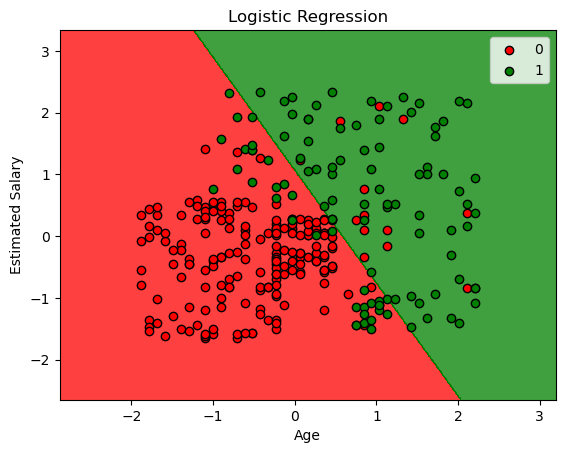

In [20]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

x_set, y_set = x_train, y_train

# generates every pixel in the table. meshgrid creates one entry point x1 to x2
x1, x2 = np.meshgrid(
    np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01),
    np.arange(start=x_set[:, 1].min() - 1, stop=x_set[:, 1].max() + 1, step=0.01)
)

# classifies every pixel as 0 or 1
plt.contourf(x1, x2, clf.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
             alpha=0.75, cmap=ListedColormap(("red", "green")))

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
                c=ListedColormap(("red", "green"))(i), label=j, edgecolor="black")

plt.xlim(x1.min(), x1.max())
plt.ylim(x2.min(), x2.max())
plt.legend()
plt.title("Logistic Regression")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.show()